In [4]:
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
df = pd.read_csv('goldman_sachs.csv')

In [10]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'],errors='coerce')

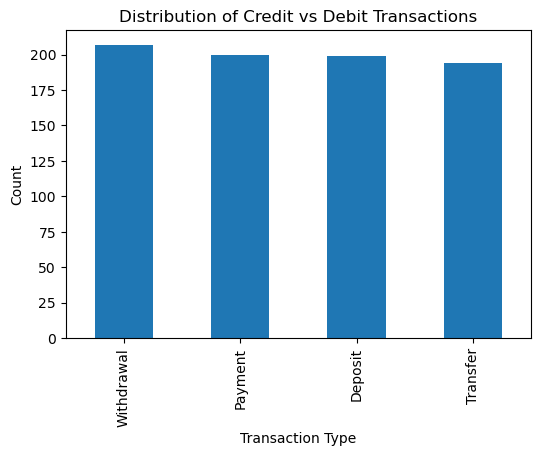

In [11]:
plt.figure(figsize=(6,4))
df['TransactionType'].value_counts().plot(kind='bar')
plt.title('Distribution of Credit vs Debit Transactions')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

In [12]:
monthly = df.groupby(pd.Grouper(key='TransactionDate', freq='M')).agg(
    Credits=('TransactionAmount', lambda x: x[x > 0].sum()),
    Debits=('TransactionAmount', lambda x: abs(x[x < 0].sum()))
).reset_index()

In [14]:
txn_count = df.groupby('AccountID').size().reset_index(name='TxnCount')

def activity_level(x):
    if x > 20:
        return 'High'
    elif x >= 10:
        return 'Medium'
    else:
        return 'Low'

txn_count['ActivityLevel'] = txn_count['TxnCount'].apply(activity_level)


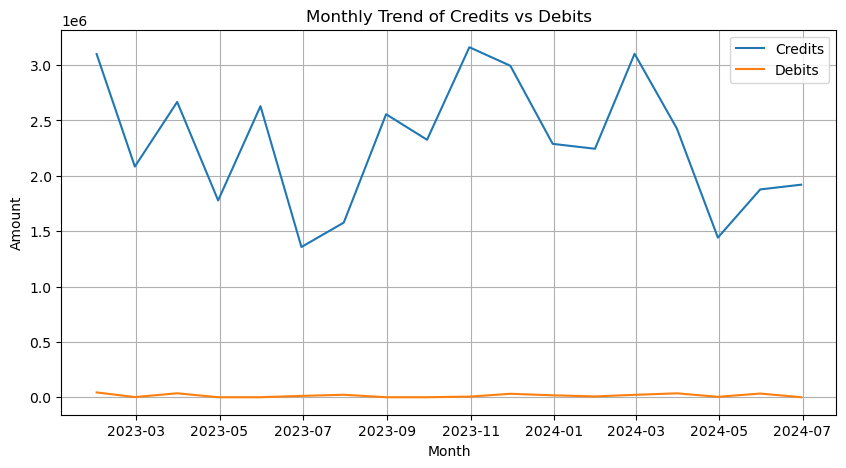

In [15]:
plt.figure(figsize=(10,5))
plt.plot(monthly['TransactionDate'], monthly['Credits'], label='Credits')
plt.plot(monthly['TransactionDate'], monthly['Debits'], label='Debits')
plt.title('Monthly Trend of Credits vs Debits')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)
plt.show()

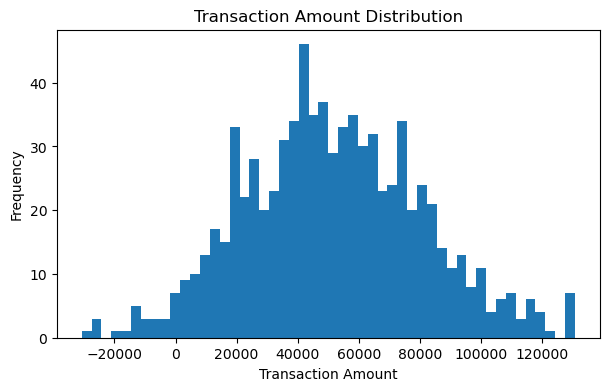

In [16]:
plt.figure(figsize=(7,4))
plt.hist(df['TransactionAmount'], bins=50)
plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()


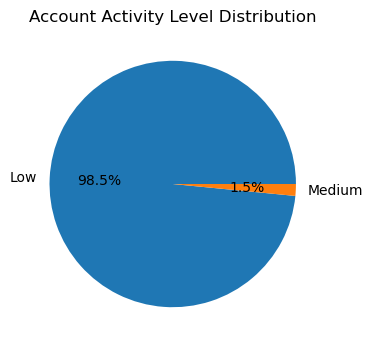

In [17]:
plt.figure(figsize=(6,4))
txn_count['ActivityLevel'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Account Activity Level Distribution')
plt.ylabel('')
plt.show()


In [22]:
balance_volatility = df.groupby('AccountID').agg(
    AvgBalance=('AccountBalance', 'mean'),
    StdBalance=('AccountBalance', 'std')
).reset_index()



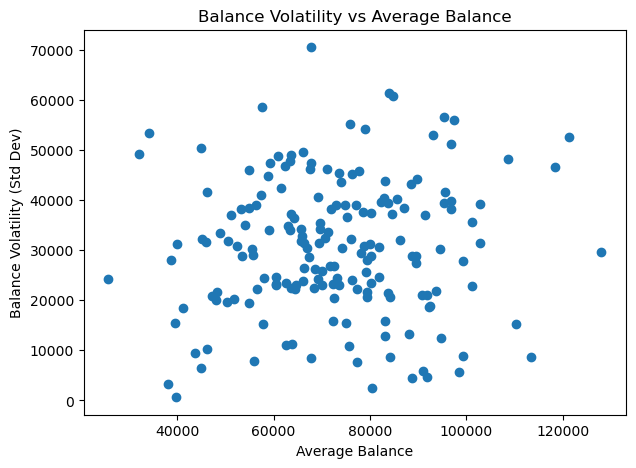

In [23]:
plt.figure(figsize=(7,5))
plt.scatter(balance_volatility['AvgBalance'], balance_volatility['StdBalance'])
plt.title('Balance Volatility vs Average Balance')
plt.xlabel('Average Balance')
plt.ylabel('Balance Volatility (Std Dev)')
plt.show()
